# Assignment 3: Exploratory Data Analysis of Row Crop Fields

**Objective.** Transparently explore the 25 real USDA-derived fields finalized in Assignment 2. This notebook reports distributions, observed associations, crop transitions, and classification agreement—never causal effects.

## 1. Data provenance

The sole analysis table is `data/assignment-02/field_summary.csv`, inherited from USDA NASS Crop Sequence Boundaries and annual 30 m Cropland Data Layer zonal extraction. The run records its Git SHA and SHA-256 in `eda_summary.json`.

## 2. Imports and reproducibility settings

In [1]:
from pathlib import Path
import sys, json
import pandas as pd
from IPython.display import display, Image
ROOT=Path.cwd()
if ROOT.name=='notebooks': ROOT=ROOT.parent
sys.path.insert(0,str(ROOT/'data/assignment-03/scripts'))
import run_assignment_03_eda as eda
pd.set_option('display.max_columns',40)
YEARS=[2020,2021,2022,2023]

## 3. Source loading and explicit validation

`load_validate` asserts 25 unique genuine identifiers, South Carolina FIPS 45, positive acreage/pixels, bounded percentages, annual coverage, valid booleans, and no duplicate records.

In [2]:
df=eda.load_validate()
print('Shape:',df.shape,'Unique fields:',df.field_id.nunique())
display(df.head(3))

Shape: (25, 30) Unique fields: 25


,field_id,CSBID,STATEFIPS,CSBACRES,county,source_attribute,CDL2020,CDL2021,CDL2022,CDL2023,crop_code_2020,crop_2020,dominant_pct_2020,valid_pixels_2020,matches_csb_2020,crop_code_2021,crop_2021,dominant_pct_2021,valid_pixels_2021,matches_csb_2021,crop_code_2022,crop_2022,dominant_pct_2022,valid_pixels_2022,matches_csb_2022,crop_code_2023,crop_2023,dominant_pct_2023,valid_pixels_2023,matches_csb_2023
0,451623001001160,451623001001160,45,4.233174,1,NaN,37,37,37,176,37,Other Hay/Non Alfalfa,77.272727,22,True,37,Other Hay/Non Alfalfa,54.545455,22,True,37,Other Hay/Non Alfalfa,50.000000,22,True,176,Grassland/Pasture,54.545455,22,True
1,451623001001187,451623001001187,45,2.941068,1,NaN,37,176,176,37,37,Other Hay/Non Alfalfa,76.923077,13,True,176,Grassland/Pasture,53.846154,13,True,176,Grassland/Pasture,61.538462,13,True,176,Grassland/Pasture,38.461538,13,False
2,451623001001196,451623001001196,45,17.514312,1,NaN,37,37,37,37,37,Other Hay/Non Alfalfa,75.000000,84,True,37,Other Hay/Non Alfalfa,67.857143,84,True,37,Other Hay/Non Alfalfa,58.333333,84,True,37,Other Hay/Non Alfalfa,57.142857,84,True


## 4. `.info()` and `.describe()` inspection

In [3]:
df.info()
display(df.describe(include='all').T)

<class 'pandas.DataFrame'>
RangeIndex: 25 entries, 0 to 24
Data columns (total 30 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   field_id           25 non-null     str    
 1   CSBID              25 non-null     str    
 2   STATEFIPS          25 non-null     str    
 3   CSBACRES           25 non-null     float64
 4   county             25 non-null     int64  
 5   source_attribute   0 non-null      float64
 6   CDL2020            25 non-null     int64  
 7   CDL2021            25 non-null     int64  
 8   CDL2022            25 non-null     int64  
 9   CDL2023            25 non-null     int64  
 10  crop_code_2020     25 non-null     int64  
 11  crop_2020          25 non-null     str    
 12  dominant_pct_2020  25 non-null     float64
 13  valid_pixels_2020  25 non-null     int64  
 14  matches_csb_2020   25 non-null     bool   
 15  crop_code_2021     25 non-null     int64  
 16  crop_2021          25 non-null     str 

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
field_id,25,25,451623001001160,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
CSBID,25,25,451623001001160,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
STATEFIPS,25,1,45,25,NaN,NaN,NaN,NaN,NaN,NaN,NaN
CSBACRES,25.0,NaN,NaN,NaN,6.812772,4.877871,2.636003,4.003016,4.545813,6.187809,19.141194
county,25.0,NaN,NaN,NaN,1.0,0.0,1.0,1.0,1.0,1.0,1.0
source_attribute,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
CDL2020,25.0,NaN,NaN,NaN,64.44,56.958377,28.0,37.0,37.0,37.0,176.0
CDL2021,25.0,NaN,NaN,NaN,120.4,69.5,37.0,37.0,176.0,176.0,176.0
CDL2022,25.0,NaN,NaN,NaN,137.08,63.697802,37.0,37.0,176.0,176.0,176.0
CDL2023,25.0,NaN,NaN,NaN,119.88,70.195157,24.0,37.0,176.0,176.0,176.0


## 5. Missing values and duplicate checks

The intentionally blank `source_attribute` is absent source metadata, not evidence that records should be discarded.

In [4]:
display(pd.DataFrame({'missing':df.isna().sum(),'unique_including_missing':df.nunique(dropna=False)}))
print('Duplicate rows:',df.duplicated().sum())

,missing,unique_including_missing
field_id,0,25
CSBID,0,25
STATEFIPS,0,1
CSBACRES,0,25
county,0,1
source_attribute,25,1
CDL2020,0,3
CDL2021,0,2
CDL2022,0,2
CDL2023,0,3


Duplicate rows: 0


## 6. Categorical profiles

In [5]:
for y in YEARS:
 print(f'\n{y}')
 display(df[f'crop_{y}'].value_counts().rename('field_count').to_frame())


2020


,field_count
crop_2020,
Other Hay/Non Alfalfa,19
Grassland/Pasture,4
Oats,2



2021


,field_count
crop_2021,
Grassland/Pasture,15
Other Hay/Non Alfalfa,10



2022


,field_count
crop_2022,
Grassland/Pasture,17
Other Hay/Non Alfalfa,8



2023


,field_count
crop_2023,
Grassland/Pasture,18
Other Hay/Non Alfalfa,6
Winter Wheat,1


## 7. Derived field metrics

All metrics are transparent transformations of the four annual crop, confidence, valid-pixel, and match columns. Assertions are embedded in `derive`.

In [6]:
metrics=eda.derive(df)
display(metrics.head())
display(metrics[['mean_dominant_pct','crop_transition_count','unique_dominant_crop_count','raster_csb_match_rate']].describe())

,field_id,CSBID,STATEFIPS,county,CSBACRES,mean_dominant_pct,median_dominant_pct,min_dominant_pct,max_dominant_pct,dominant_pct_range,mean_valid_pixels,crop_transition_count,unique_dominant_crop_count,raster_csb_match_rate,ever_raster_csb_mismatch,acreage_iqr_outlier,confidence_iqr_outlier
0,451623001001160,451623001001160,45,1,4.233174,59.090909,54.545455,50.000000,77.272727,27.272727,22.0,1,2,100.0,False,False,False
1,451623001001187,451623001001187,45,1,2.941068,57.692308,57.692308,38.461538,76.923077,38.461539,13.0,1,2,75.0,True,False,False
2,451623001001196,451623001001196,45,1,17.514312,64.583333,63.095238,57.142857,75.000000,17.857143,84.0,0,1,100.0,False,True,False
3,451623001001204,451623001001204,45,1,3.307537,65.000000,66.666666,53.333333,73.333333,20.000000,15.0,1,2,100.0,False,False,False
4,451623001001218,451623001001218,45,1,6.187809,63.888889,59.259259,51.851852,85.185185,33.333333,27.0,1,2,75.0,True,False,False


,mean_dominant_pct,crop_transition_count,unique_dominant_crop_count,raster_csb_match_rate
count,25.000000,25.000000,25.000000,25.000000
mean,68.096431,0.840000,1.760000,94.000000
std,12.381947,0.687992,0.597216,13.070323
min,44.863013,0.000000,1.000000,50.000000
25%,59.090909,0.000000,1.000000,100.000000
50%,67.307693,1.000000,2.000000,100.000000
75%,71.538461,1.000000,2.000000,100.000000
max,96.052631,2.000000,3.000000,100.000000


## 8. IQR outlier analysis

The standard 1.5×IQR rule flags observations for review. Valid outliers are retained; no row is silently removed.

In [7]:
display(metrics.loc[metrics.acreage_iqr_outlier|metrics.confidence_iqr_outlier,['field_id','CSBACRES','mean_dominant_pct','acreage_iqr_outlier','confidence_iqr_outlier']])

,field_id,CSBACRES,mean_dominant_pct,acreage_iqr_outlier,confidence_iqr_outlier
2,451623001001196,17.514312,64.583333,True,False
5,451623001001219,4.545813,95.000000,False,True
11,451623001001250,12.640829,85.593220,True,False
13,451623001001257,19.141194,85.882353,True,False
17,451623001001262,15.704763,44.863013,True,False
19,451623001001266,14.144361,71.538461,True,False
20,451623001001267,4.753305,96.052631,False,True


## 9. Visual 1 — Acreage distribution

Quartiles and retained IQR outliers provide context for this selected 25-field sample.

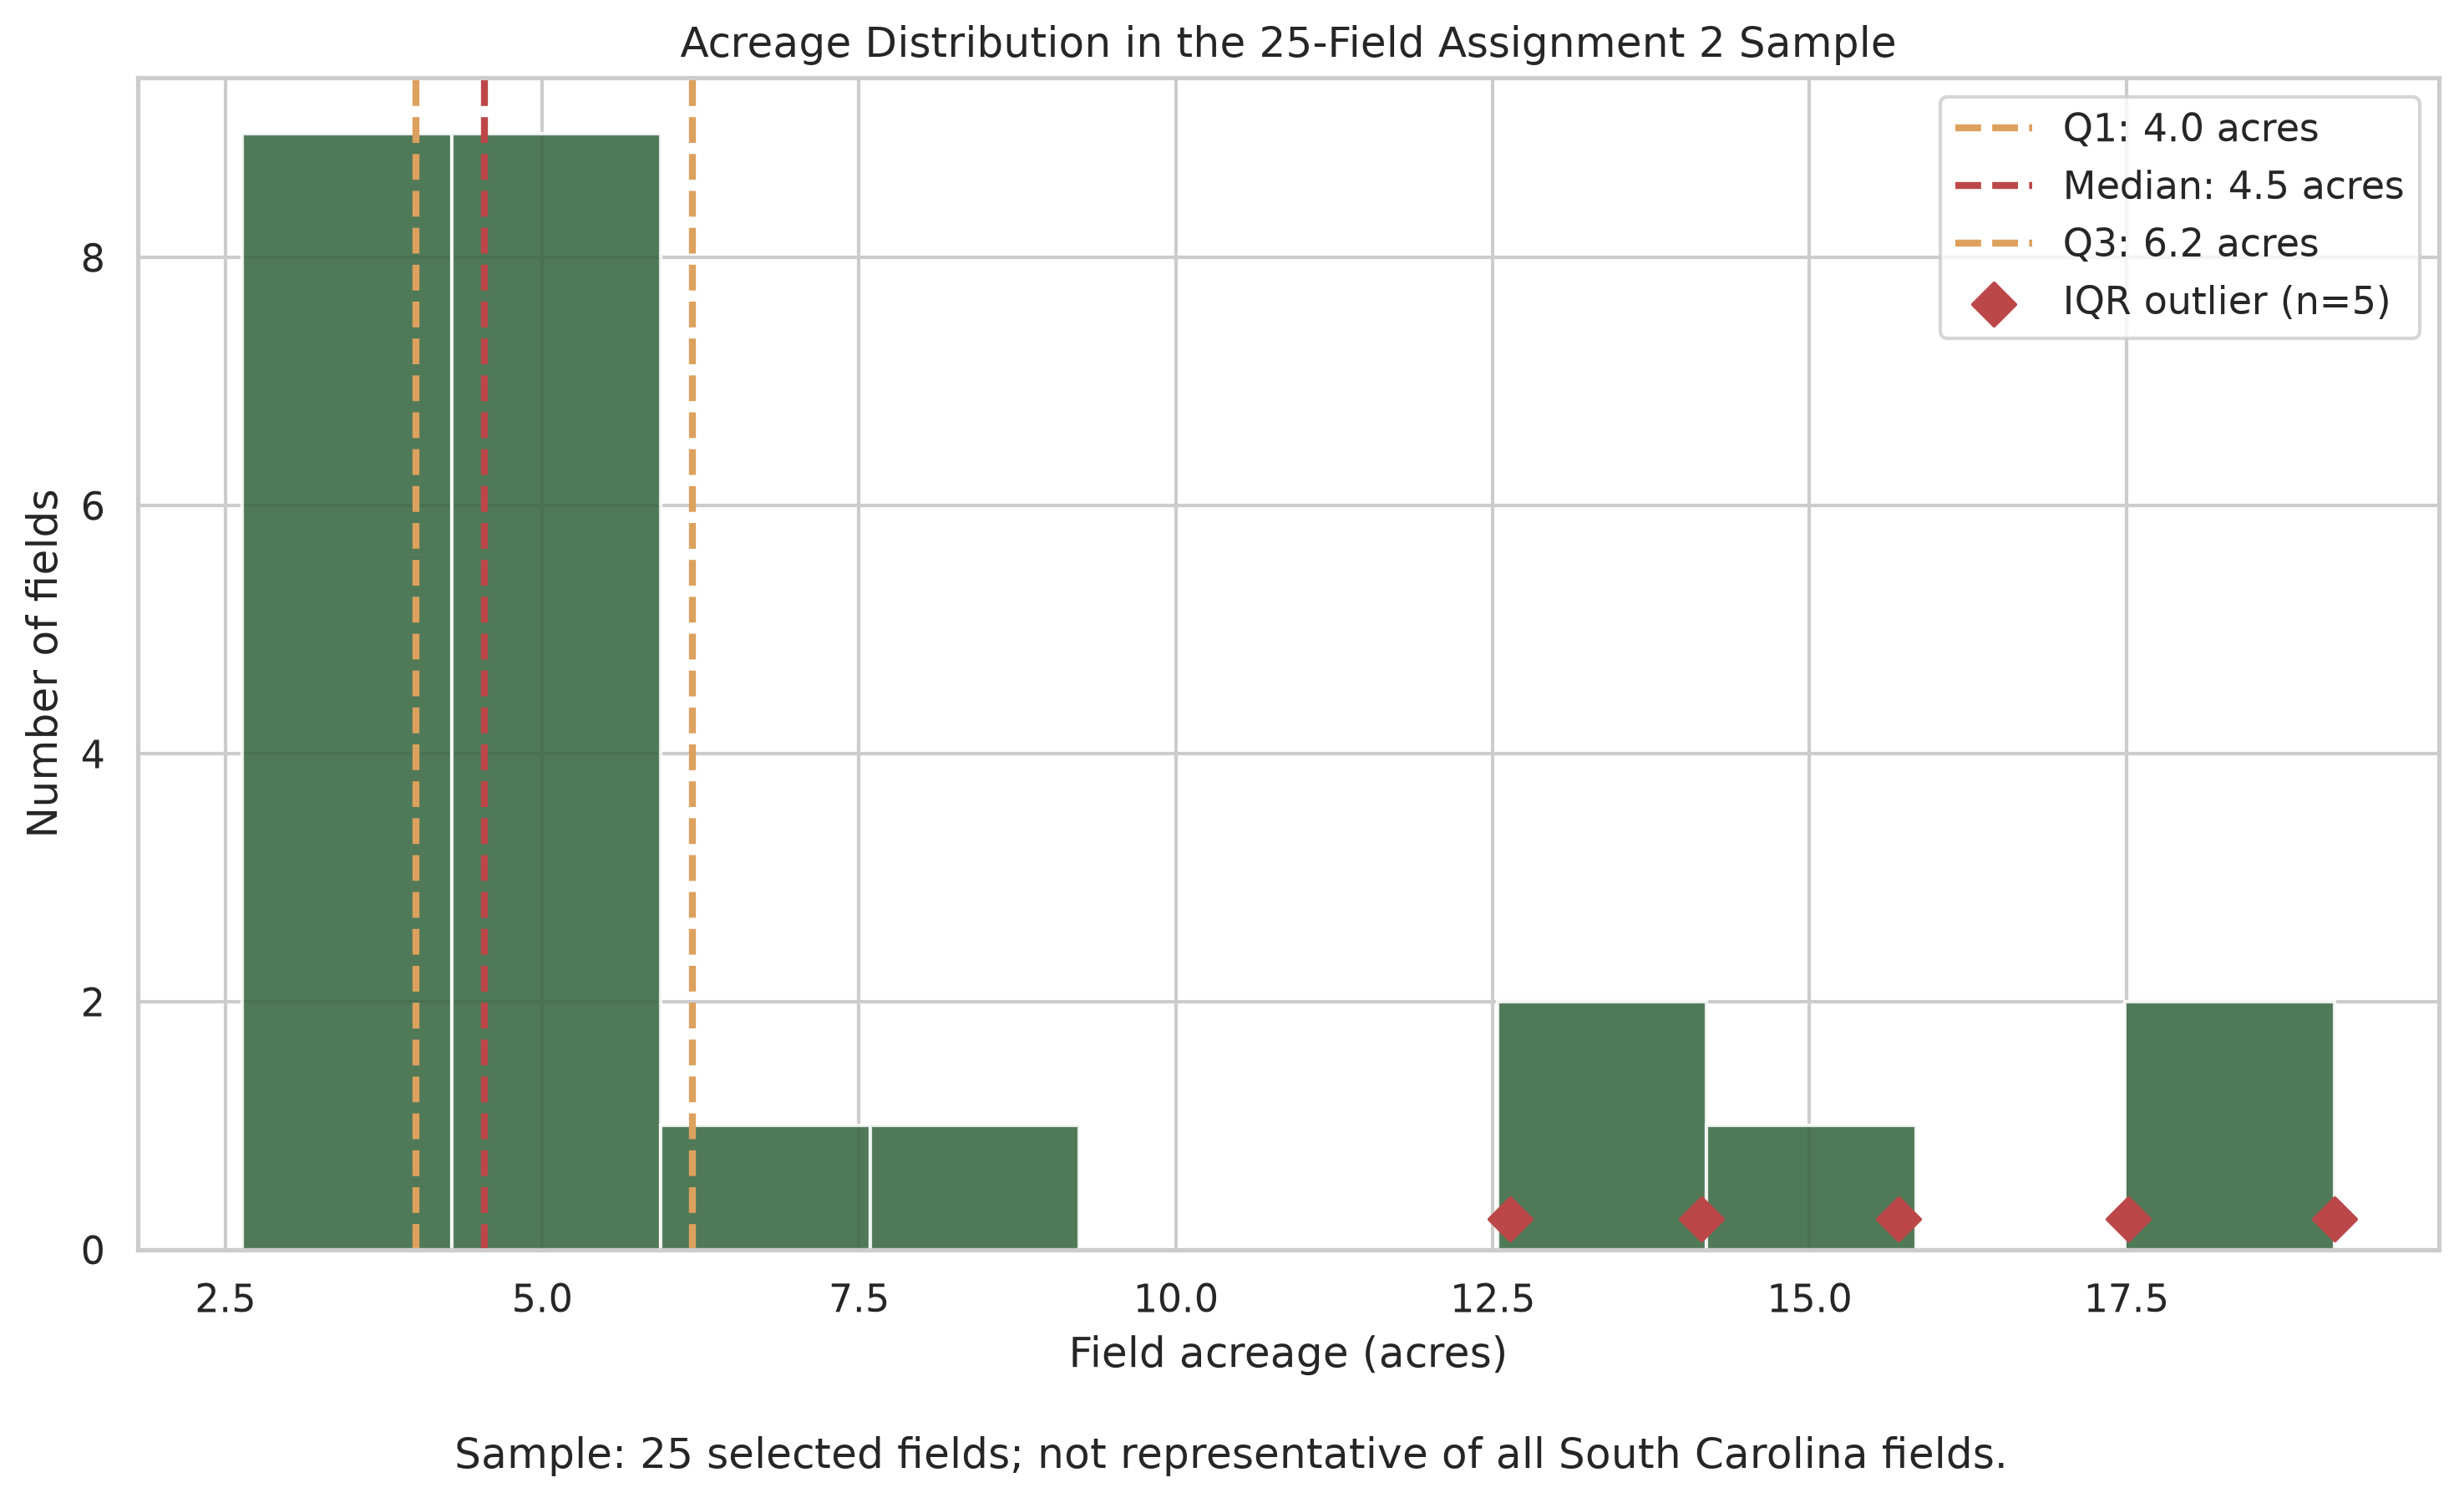

In [8]:
display(Image(filename=str(ROOT/'data/assignment-03/output/visualizations/01_acreage_distribution.png'),width=900))

## 10. Visual 2 — Acreage and classification confidence

Field points encode transition counts and whether any raster/CSB mismatch occurred. Correlations are descriptive.

,value
sample_size,25.000000
spearman_rho,0.146923
spearman_p_value,0.483413
pearson_r,0.071906
pearson_p_value,0.732677


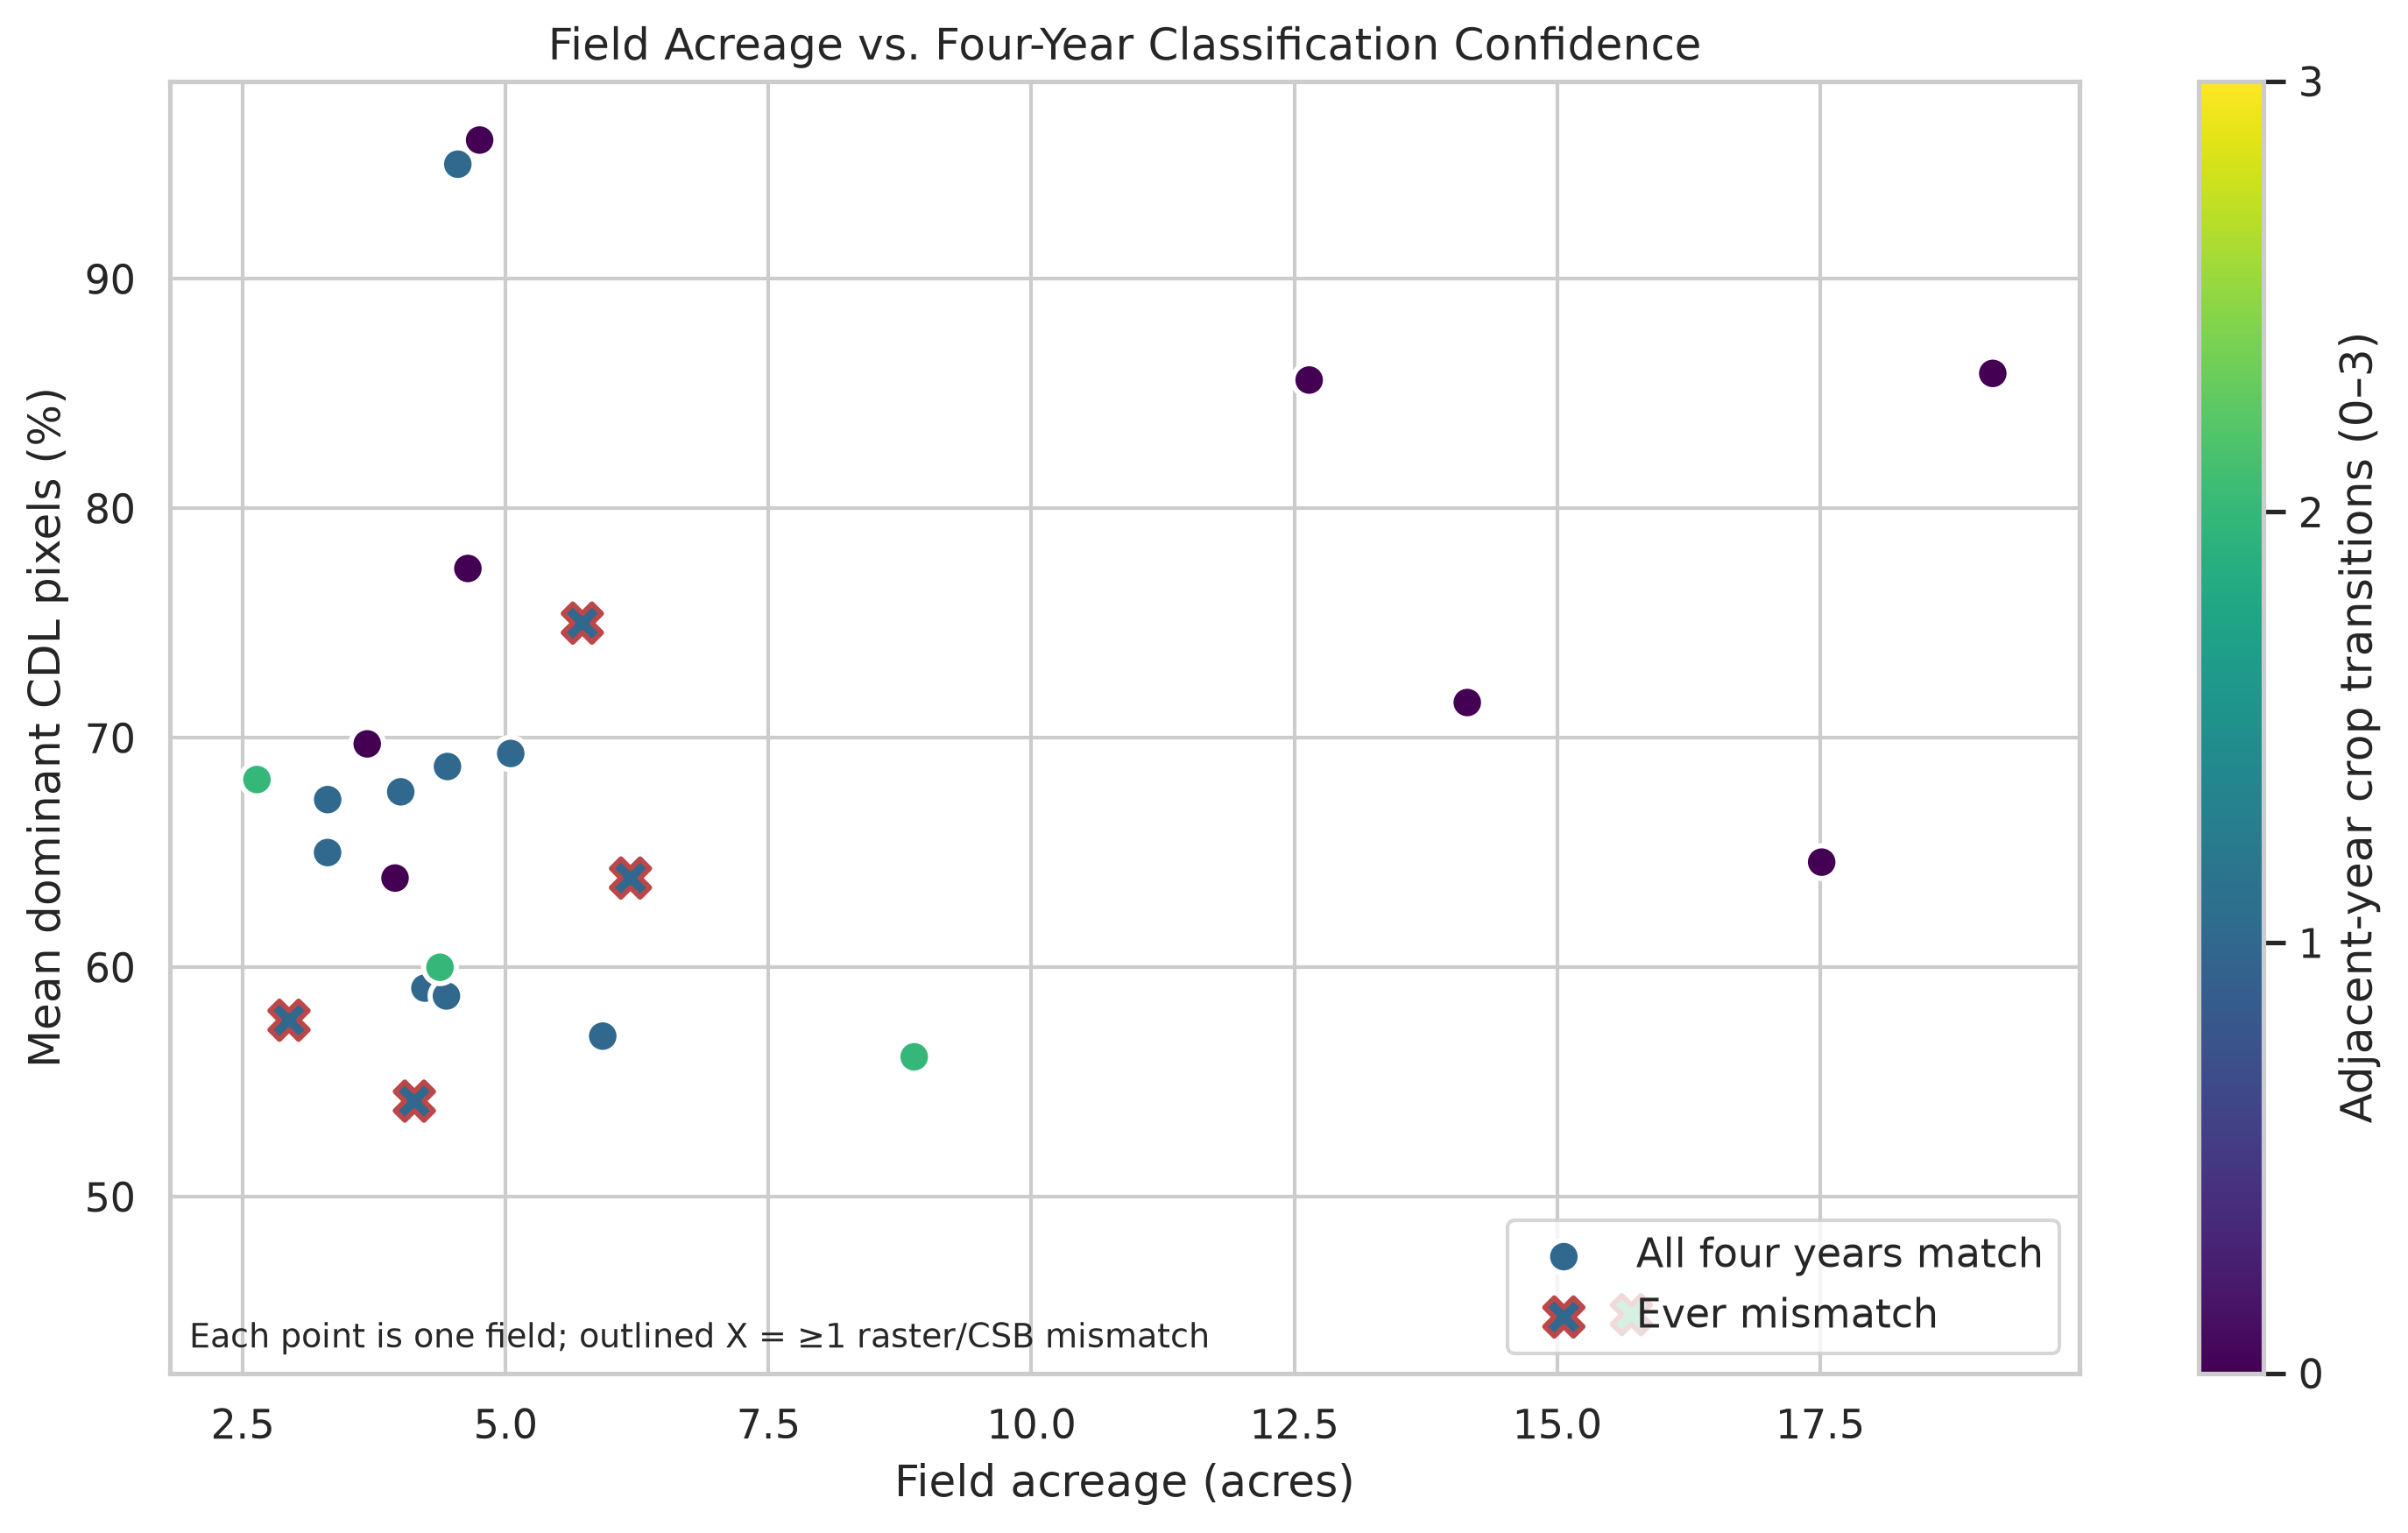

In [9]:
summary=json.loads((ROOT/'data/assignment-03/output/eda_summary.json').read_text())
display(pd.Series(summary['visual_2_correlations']).to_frame('value'))
display(Image(filename=str(ROOT/'data/assignment-03/output/visualizations/02_acreage_vs_classification_confidence.png'),width=900))

## 11. Visual 3 — Spearman correlation heatmap

Identifiers and nominal crop codes are excluded. With only 25 fields, estimates may be unstable.

,CSBACRES,mean_dominant_pct,min_dominant_pct,dominant_pct_range,crop_transition_count,unique_dominant_crop_count,raster_csb_match_rate
CSBACRES,1.000000,0.146923,0.152660,-0.313582,-0.234754,-0.157459,-0.080664
mean_dominant_pct,0.146923,1.000000,0.914806,-0.362062,-0.580529,-0.624958,0.404426
min_dominant_pct,0.152660,0.914806,1.000000,-0.547244,-0.675738,-0.713320,0.518332
dominant_pct_range,-0.313582,-0.362062,-0.547244,1.000000,0.413733,0.385591,-0.192895
crop_transition_count,-0.234754,-0.580529,-0.675738,0.413733,1.000000,0.938738,-0.302221
unique_dominant_crop_count,-0.157459,-0.624958,-0.713320,0.385591,0.938738,1.000000,-0.395988
raster_csb_match_rate,-0.080664,0.404426,0.518332,-0.192895,-0.302221,-0.395988,1.000000


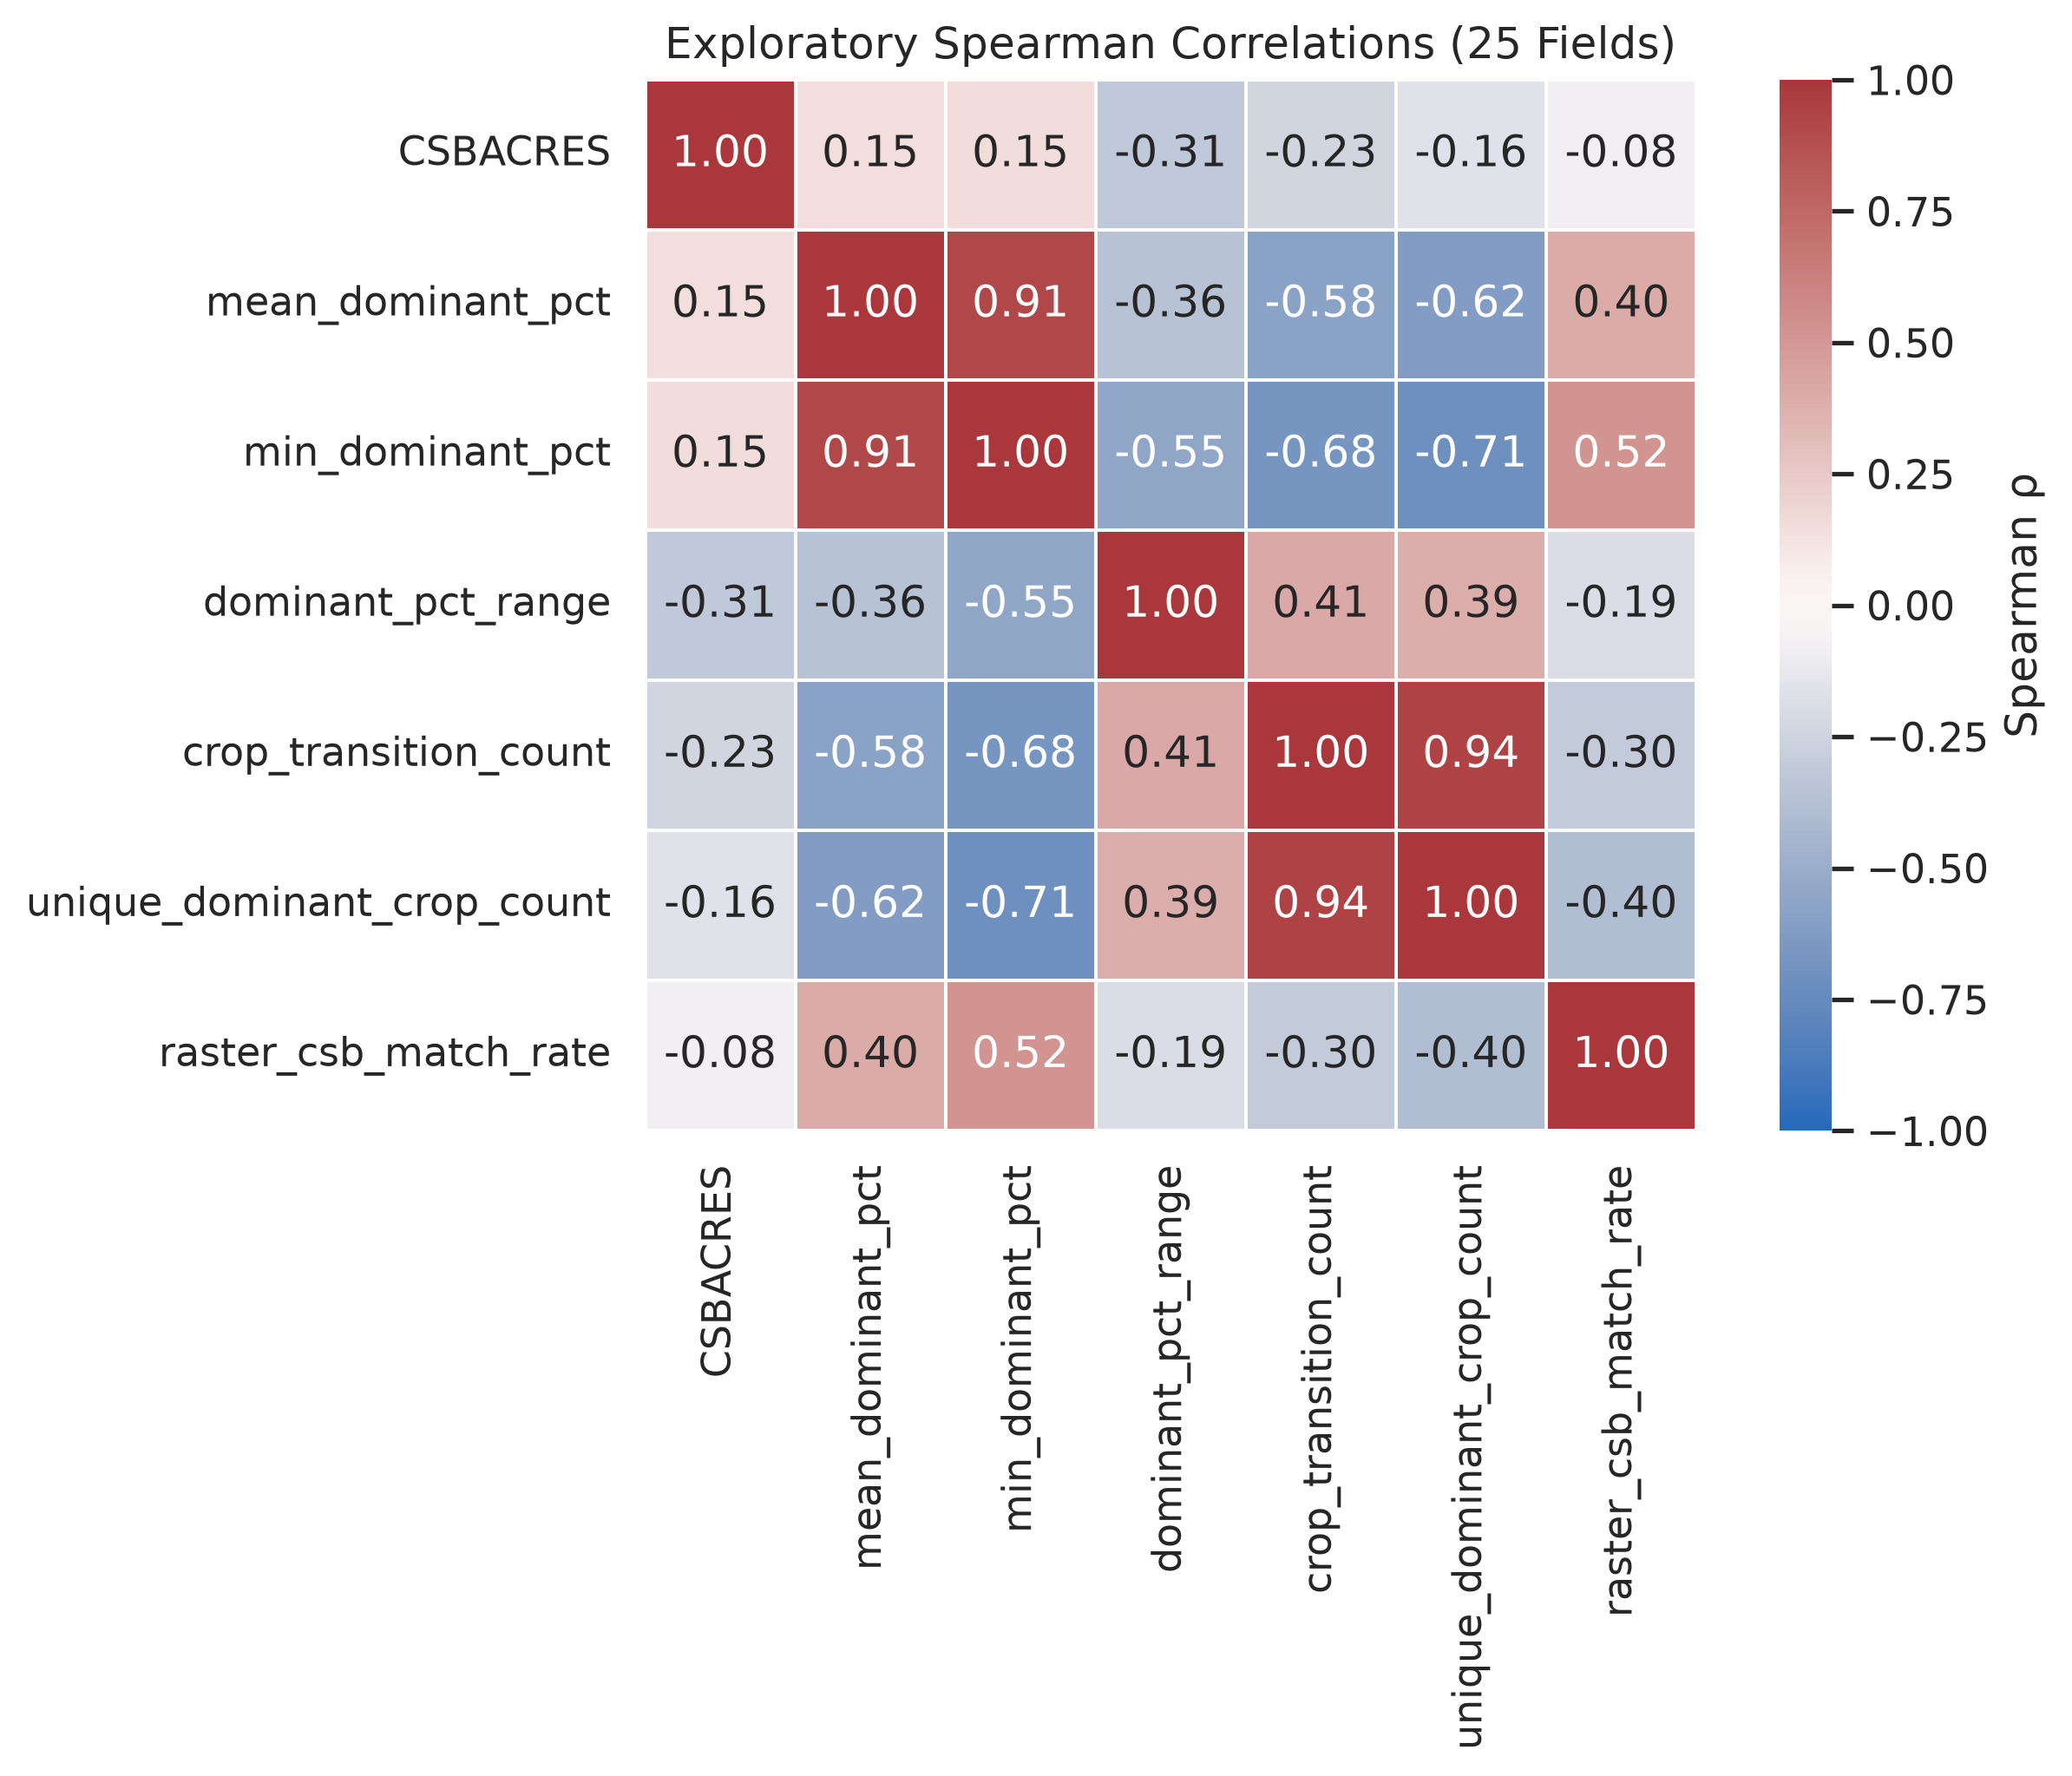

In [10]:
display(pd.read_csv(ROOT/'data/assignment-03/output/correlation_matrix_spearman.csv',index_col=0))
display(Image(filename=str(ROOT/'data/assignment-03/output/visualizations/03_metric_correlation_heatmap.png'),width=850))

## 12. Visual 4 — Crop composition over time

Counts use the observed annual dominant crop names without interpolation.

,year,crop,field_count,field_pct
0,2020,Grassland/Pasture,4,16.0
1,2020,Oats,2,8.0
2,2020,Other Hay/Non Alfalfa,19,76.0
3,2021,Grassland/Pasture,15,60.0
4,2021,Other Hay/Non Alfalfa,10,40.0
5,2022,Grassland/Pasture,17,68.0
6,2022,Other Hay/Non Alfalfa,8,32.0
7,2023,Grassland/Pasture,18,72.0
8,2023,Other Hay/Non Alfalfa,6,24.0
9,2023,Winter Wheat,1,4.0


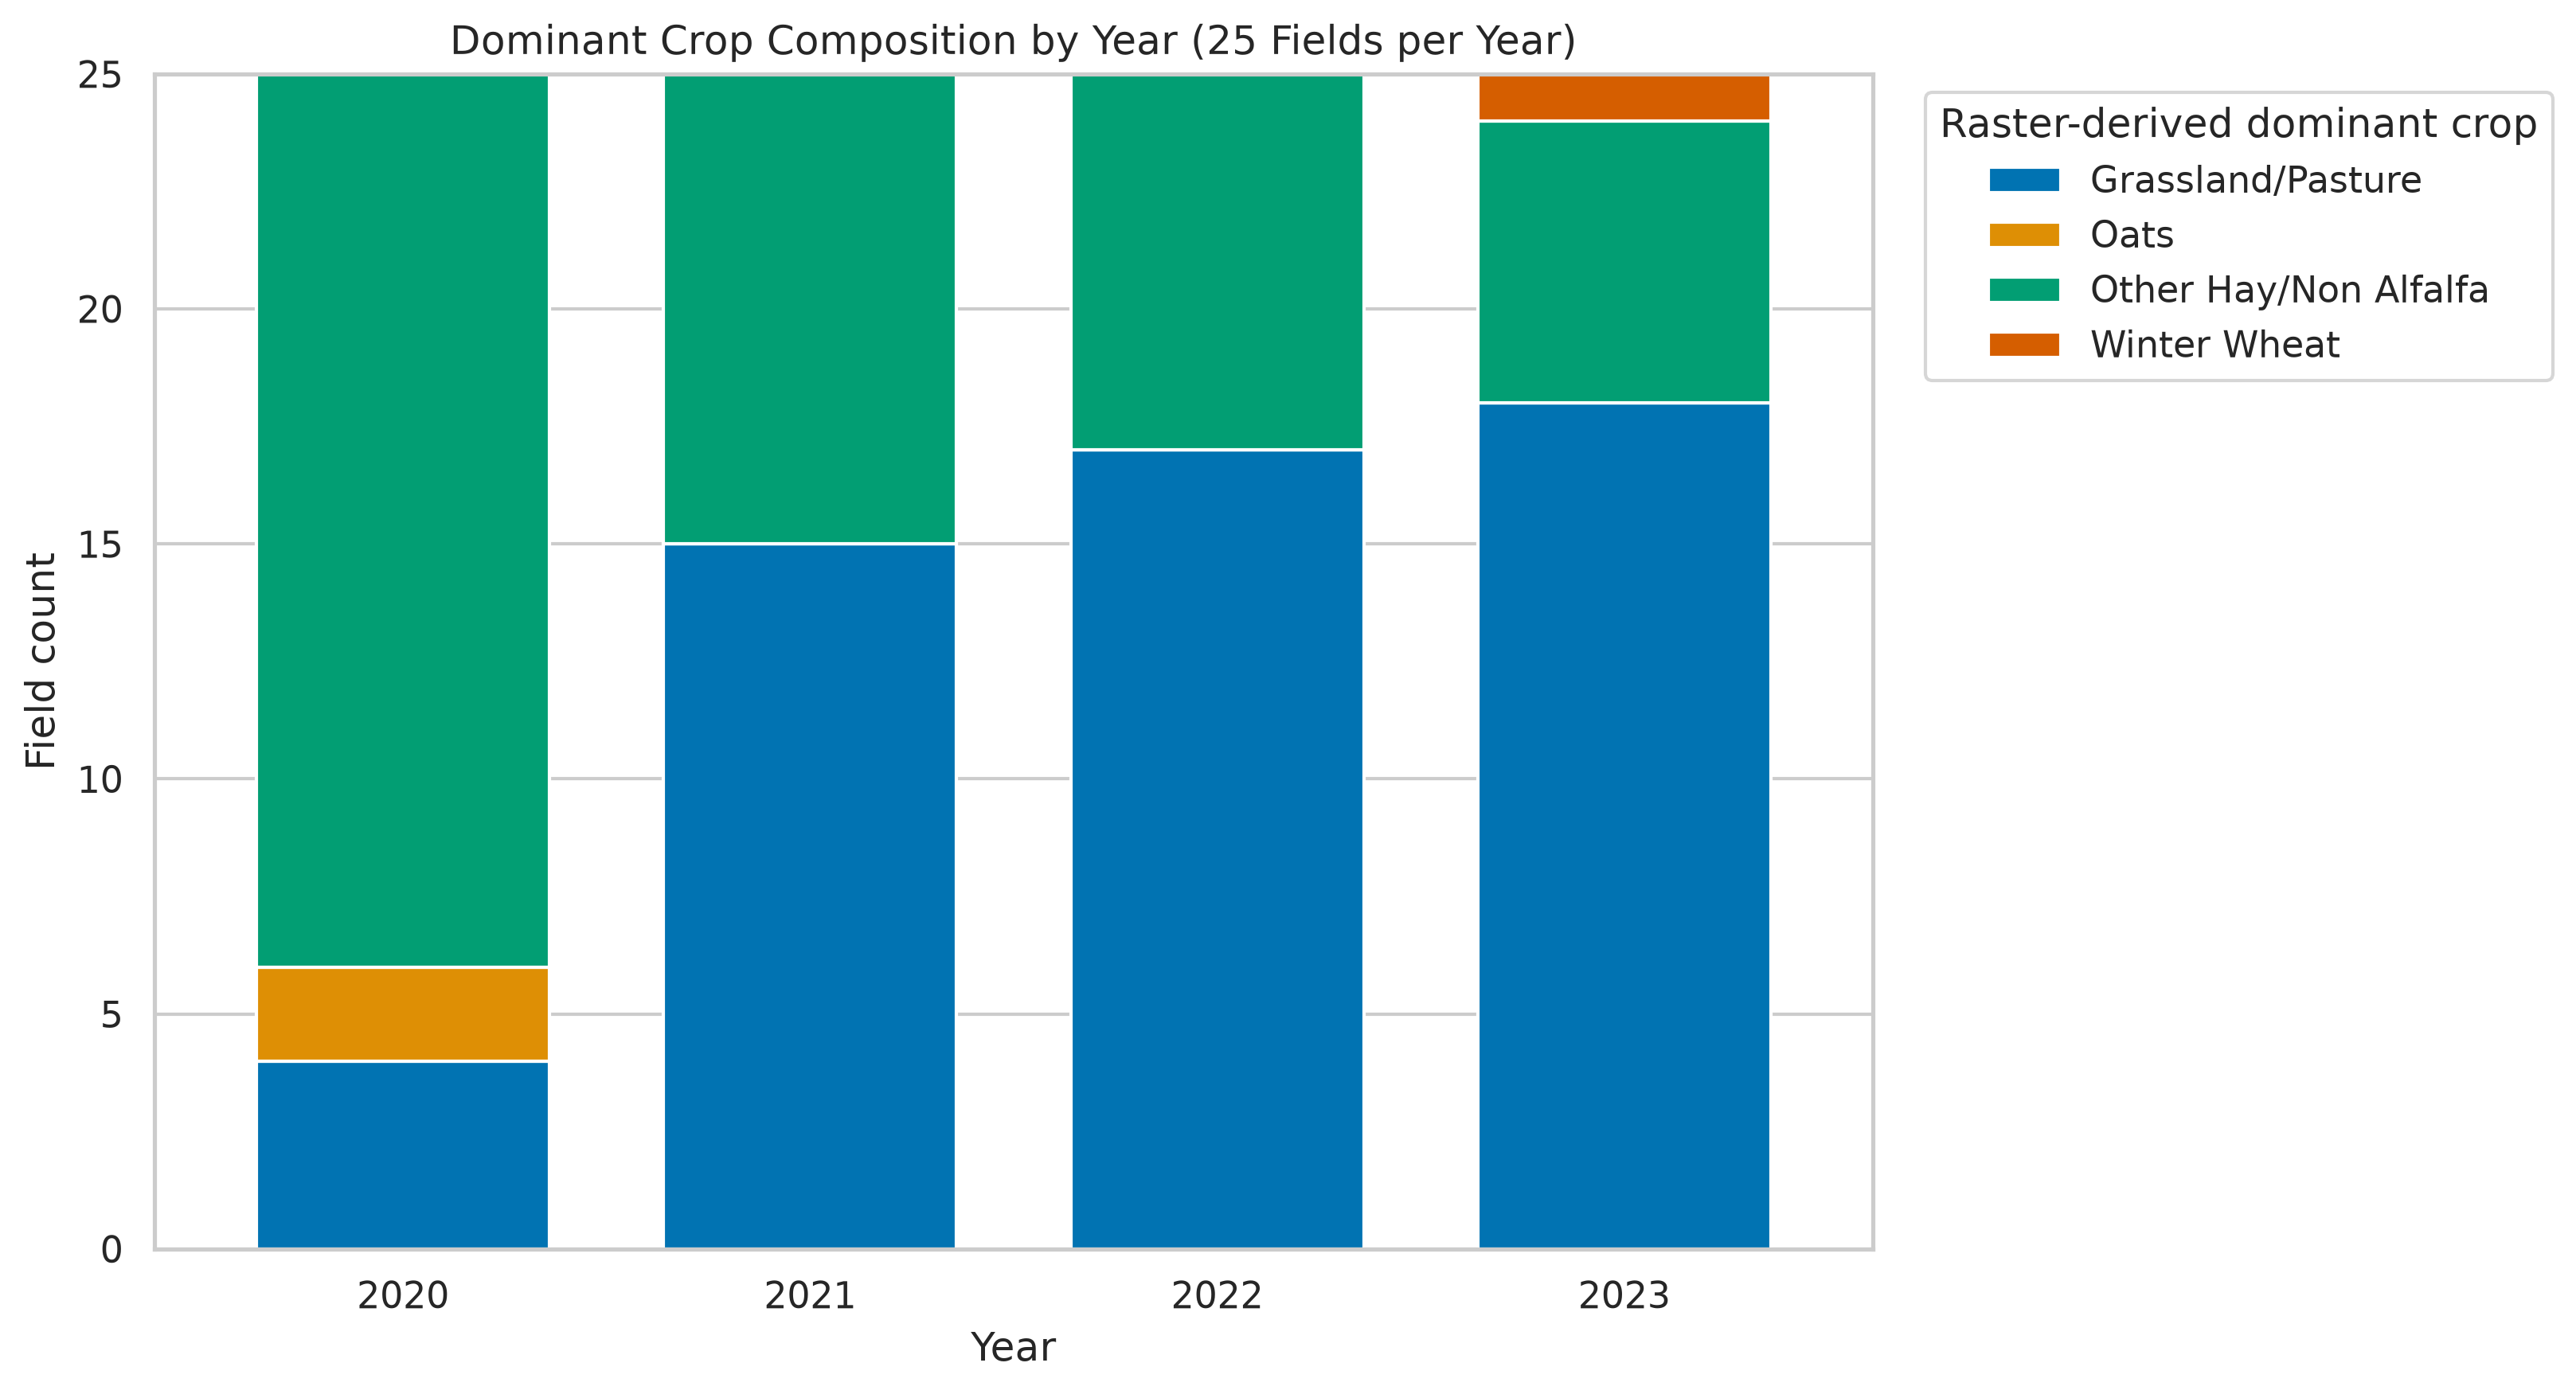

In [11]:
display(pd.read_csv(ROOT/'data/assignment-03/output/crop_composition_by_year.csv'))
display(Image(filename=str(ROOT/'data/assignment-03/output/visualizations/04_crop_composition_by_year.png'),width=950))

## 13. Key findings

The executed outputs above quantify acreage, confidence, transitions, composition, and agreement. Interpretations are observational and apply only to these 25 selected fields.

In [12]:
print('Median acres:',metrics.CSBACRES.median())
print('Mean confidence:',metrics.mean_dominant_pct.mean())
print('Transition distribution:',metrics.crop_transition_count.value_counts().sort_index().to_dict())
print('Overall match rate:',summary['raster_csb_match_rate_overall'])

Median acres: 4.545813303363282
Mean confidence: 68.09643127999999
Transition distribution: {0: 8, 1: 13, 2: 4}
Overall match rate: 94.0


## 14. Limitations

The sample contains only 25 fields in one selected South Carolina county FIPS, four annual observations, and 30 m CDL pixels. Dominant-pixel summaries discard within-field heterogeneity, and small-field edges may affect results. Correlations are exploratory—not causal. No soil, yield, or weather measurements are present.

## 15. Dashboard-asset decisions

Crop composition communicates annual categorical patterns; acreage versus classification confidence supports field-level inspection. The dashboard exports have a wider presentation layout and explanatory annotations.

## 16. Data-authenticity statement

No synthetic fields or missing agronomic variables were created. Every observation originates in finalized Assignment 2 products; derived metrics are documented transformations. Soil, yield, weather, and management variables were neither present nor invented.